In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

sns.set_style("whitegrid")

In [3]:
train = pd.read_csv("/Users/deannalakshman/Desktop/IIT/YEAR 2/SEM 2/DSPLC/Coursework technical/featured_dataset/train_featured.csv")
validation = pd.read_csv("/Users/deannalakshman/Desktop/IIT/YEAR 2/SEM 2/DSPLC/Coursework technical/featured_dataset/val_featured.csv")
test = pd.read_csv("/Users/deannalakshman/Desktop/IIT/YEAR 2/SEM 2/DSPLC/Coursework technical/featured_dataset/test_featured.csv")

print("Train Shape:", train.shape)
print("Validation Shape:", validation.shape)
print("Test Shape:", test.shape)

Train Shape: (27499, 37)
Validation Shape: (2749, 37)
Test Shape: (4318, 33)


In [8]:
train.head(5)
train.info()
train.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Reservation-id           27499 non-null  int64  
 1   Gender                   27499 non-null  object 
 2   Age                      27499 non-null  int64  
 3   Ethnicity                27499 non-null  object 
 4   Educational_Level        27499 non-null  object 
 5   Income                   27499 non-null  object 
 6   Country_region           27499 non-null  object 
 7   Hotel_Type               27499 non-null  object 
 8   Expected_checkin         27499 non-null  object 
 9   Expected_checkout        27499 non-null  object 
 10  Booking_date             27499 non-null  object 
 11  Adults                   27499 non-null  float64
 12  Children                 27499 non-null  int64  
 13  Babies                   27499 non-null  int64  
 14  Meal_Type             

,count,mean,std,min,25%,50%,75%,max
Reservation-id,27499.0,5.016461e+07,2.886911e+07,3154.0,25239432.0,50149955.0,75182883.00,99999005.0
Age,27499.0,4.397745e+01,1.530315e+01,18.0,31.0,44.0,57.00,70.0
Adults,27499.0,2.292011e+00,1.087015e+00,1.0,2.0,2.0,3.00,4.5
Children,27499.0,1.509546e+00,7.987609e-01,0.0,1.0,1.0,2.00,3.0
Babies,27499.0,3.515401e-01,5.733259e-01,0.0,0.0,0.0,1.00,2.0
Discount_Rate,27499.0,1.249518e+01,1.120604e+01,0.0,5.0,10.0,20.00,40.0
Room_Rate,27499.0,1.751365e+02,4.387709e+01,100.0,137.0,175.0,214.00,250.0
Reservation_Status_Code,27499.0,1.304884e+00,6.053875e-01,1.0,1.0,1.0,1.00,3.0
Cancelled,27499.0,1.503327e-01,3.574038e-01,0.0,0.0,0.0,0.00,1.0
No_Show,27499.0,7.727554e-02,2.670330e-01,0.0,0.0,0.0,0.00,1.0


## PLOTS

## Plot 1: Reservation Status Distribution

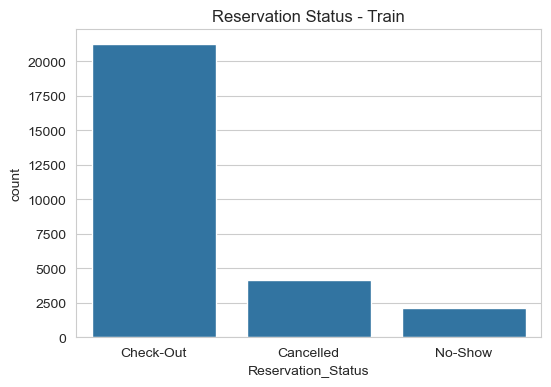

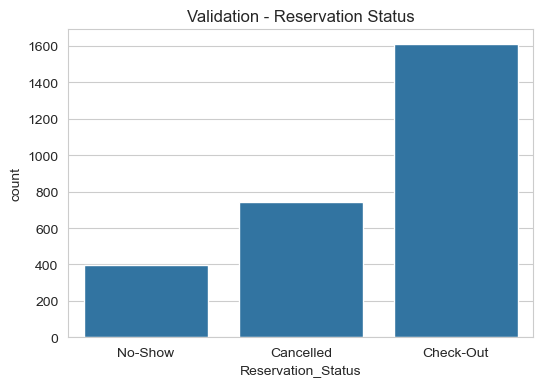

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Reservation_Status", data=train)
plt.title("Reservation Status - Train")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Reservation_Status', data=validation)
plt.title("Validation - Reservation Status")
plt.show()


## Plot 2: Lead Time Distribution

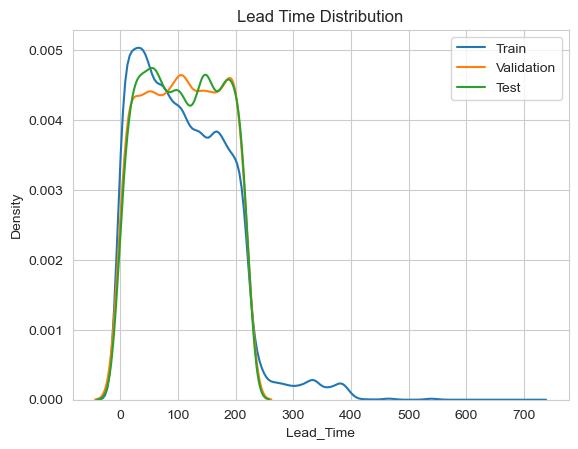

In [10]:
plt.figure()

sns.kdeplot(train["Lead_Time"], label="Train")
sns.kdeplot(validation["Lead_Time"], label="Validation")
sns.kdeplot(test["Lead_Time"], label="Test")

plt.legend()
plt.title("Lead Time Distribution")
plt.show()

## Plot 3: Room Rate Distribution Comparison

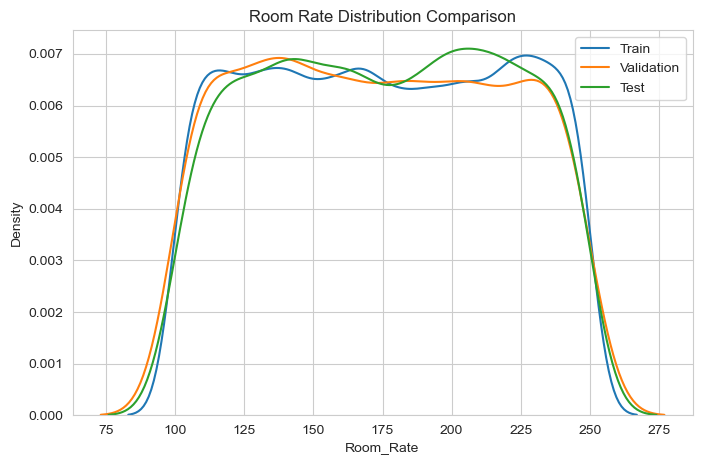

In [11]:
plt.figure(figsize=(8,5))
sns.kdeplot(train['Room_Rate'], label='Train')
sns.kdeplot(validation['Room_Rate'], label='Validation')
sns.kdeplot(test['Room_Rate'], label='Test')
plt.legend()
plt.title("Room Rate Distribution Comparison")
plt.show()


## Plot 4: Lead TIme vs Stay Duration

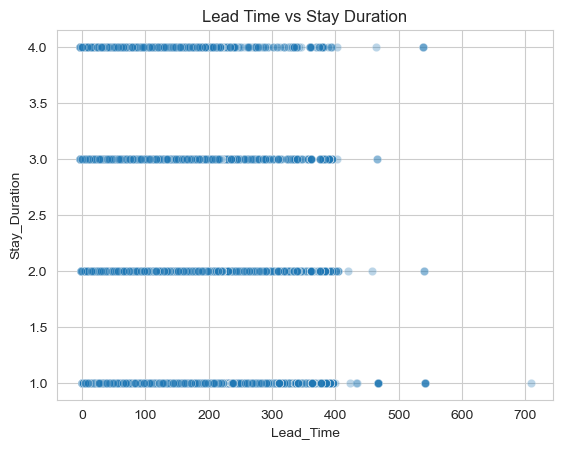

In [12]:
plt.figure()

sns.scatterplot(
    data=train,
    x="Lead_Time",
    y="Stay_Duration",
    alpha=0.3
)

plt.title("Lead Time vs Stay Duration")
plt.show()

## Plot 5 & 6: Reservation Status by Booking Month (Train and Validation)

In [23]:
monthly_status_Train = (
    train.groupby("Booking_Month")["Reservation_Status"]
    .value_counts(normalize=True)
    .unstack() * 100
)

monthly_status_Train.index = monthly_status_Train.index.map(lambda x: calendar.month_name[x])

In [24]:
monthly_status_val = (
    validation.groupby("Booking_Month")["Reservation_Status"]
    .value_counts(normalize=True)
    .unstack() * 100
)

monthly_status_val.index = monthly_status_val.index.map(lambda x: calendar.month_name[x])

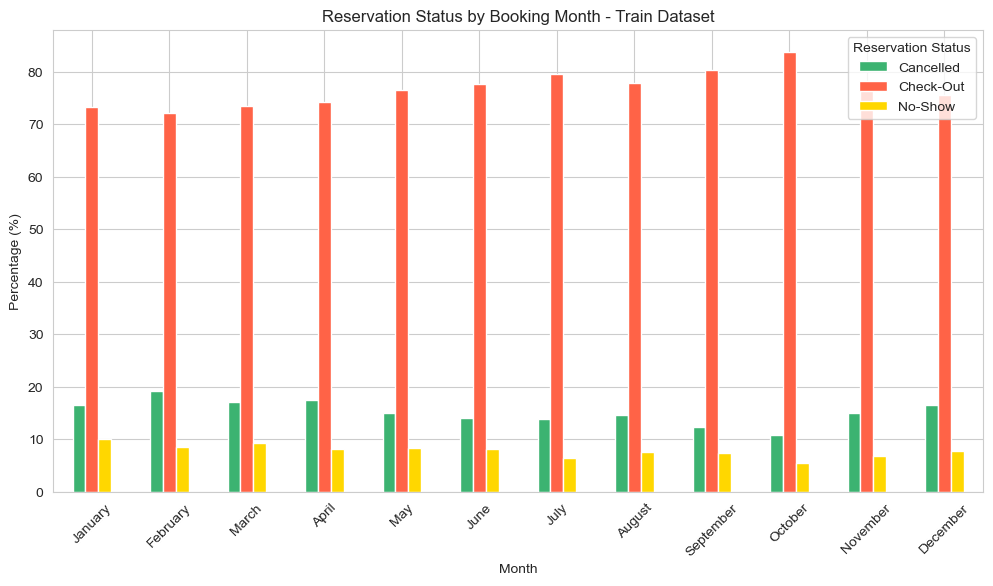

In [25]:
monthly_status_Train.plot(
    kind="bar",
    figsize=(12,6),
    color=["mediumseagreen","tomato","gold"]
)

plt.title("Reservation Status by Booking Month - Train Dataset")
plt.ylabel("Percentage (%)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.legend(title="Reservation Status")
plt.show()

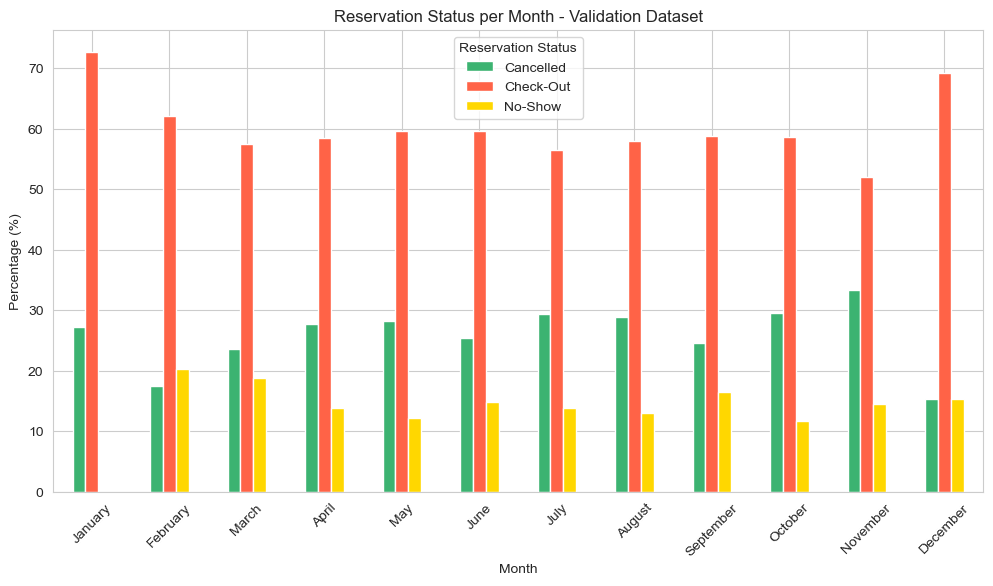

In [26]:
monthly_status_val.plot(
    kind='bar',
    figsize=(12,6),
    color=['mediumseagreen', 'tomato', 'gold']
)

plt.title('Reservation Status per Month - Validation Dataset')
plt.ylabel('Percentage (%)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend(title='Reservation Status')
plt.show()

## Plot 7: 30 day rolling average of bookings

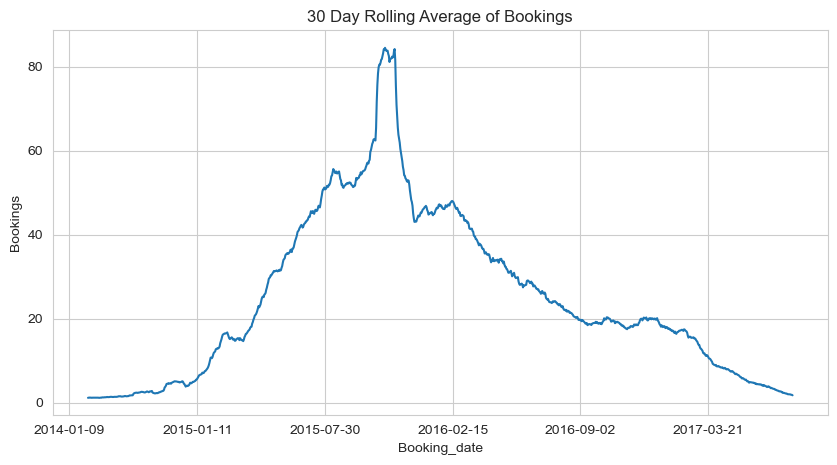

In [27]:
daily_bookings = train.groupby("Booking_date").size()

daily_bookings.rolling(30).mean().plot(figsize=(10,5))

plt.title("30 Day Rolling Average of Bookings")
plt.ylabel("Bookings")
plt.show()

## Plot 8: Stay Duration Distribution Comparison

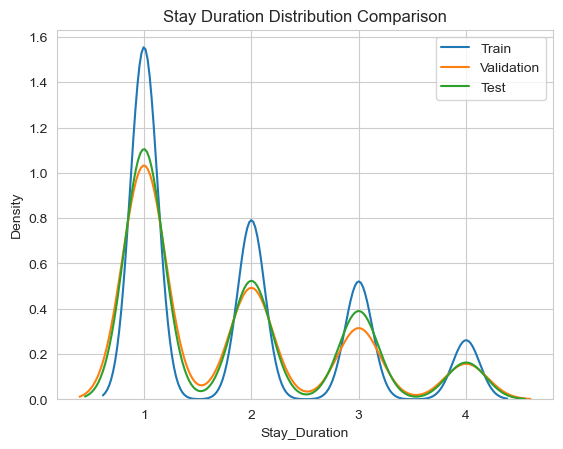

In [28]:
# Stay duration distribution comparison
plt.figure()
sns.kdeplot(train['Stay_Duration'], label='Train')
sns.kdeplot(validation['Stay_Duration'], label='Validation')
sns.kdeplot(test['Stay_Duration'], label='Test')
plt.legend()
plt.title('Stay Duration Distribution Comparison')
plt.show()
